### shapes, columns, gaps

In [1]:
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt

tr = pd.read_csv("../data/raw/train.csv", parse_dates=["timestamp"])
print(tr.shape)
print(tr.columns.tolist())
print(tr.dtypes)

# one row per (series, hour)? no duplicates?
print("series      ", tr.series_id.nunique())
print("rows/series ", tr.groupby("series_id").size().unique())
print("duplicates  ", tr.duplicated(["series_id","timestamp"]).sum())
print("time range  ", tr.timestamp.min(), "->", tr.timestamp.max())

# is the hourly grid complete for every series?
for sid, g in tr.groupby("series_id"):
    gaps = g.timestamp.sort_values().diff().dropna().value_counts()
    if len(gaps) > 1 or gaps.index[0] != pd.Timedelta("1h"):
        print("IRREGULAR:", sid, dict(gaps))
print("grid check done")

Matplotlib is building the font cache; this may take a moment.


(414720, 25)
['series_id', 'timestamp', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'trend', 'workload_intensity', 'demand_forecast', 'staffing_forecast', 'upstream_quality_forecast', 'promotion_intensity', 'shock_risk', 'maintenance_known', 'unit_reliability_forecast', 'queue_pressure_forecast', 'network_pressure_forecast', 'event_load_forecast', 'service_irregularity_risk_forecast', 'throughput_disruption_risk_forecast', 'nominal_capacity', 'zone_sin', 'zone_cos', 'target']
series_id                                         str
timestamp                              datetime64[us]
hour_sin                                      float64
hour_cos                                      float64
dow_sin                                       float64
dow_cos                                       float64
is_weekend                                    float64
trend                                         float64
workload_intensity                            float64
demand_forecast  

### are future covariates given?

In [2]:
vi = pd.read_csv("../data/raw/validation_input.csv", parse_dates=["timestamp"])
fi = pd.read_csv("../data/raw/forecast_index_validation.csv", parse_dates=["timestamp"])

print("input cols  ", vi.columns.tolist())
print("input shape ", vi.shape, "| rows/series", vi.groupby("series_id").size().unique())
print("input range ", vi.timestamp.min(), "->", vi.timestamp.max())
print("index shape ", fi.shape, "| rows/series", fi.groupby("series_id").size().unique())
print("index range ", fi.timestamp.min(), "->", fi.timestamp.max())

# THE question: do the rows you must predict have features attached?
need = set(map(tuple, fi[["series_id","timestamp"]].values))
have = set(map(tuple, vi[["series_id","timestamp"]].values))
print("forecast rows present in input:", len(need & have), "/", len(need))
print("target column in input:", "target" in vi.columns)

input cols   ['series_id', 'timestamp', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'trend', 'workload_intensity', 'demand_forecast', 'staffing_forecast', 'upstream_quality_forecast', 'promotion_intensity', 'shock_risk', 'maintenance_known', 'unit_reliability_forecast', 'queue_pressure_forecast', 'network_pressure_forecast', 'event_load_forecast', 'service_irregularity_risk_forecast', 'throughput_disruption_risk_forecast', 'nominal_capacity', 'zone_sin', 'zone_cos']
input shape  (32256, 24) | rows/series [336]
input range  2023-06-30 00:00:00 -> 2023-07-13 23:00:00
index shape  (32256, 2) | rows/series [336]
index range  2023-06-30 00:00:00 -> 2023-07-13 23:00:00
forecast rows present in input: 32256 / 32256
target column in input: False


### sorting the features

In [4]:
feat = [c for c in tr.columns if c not in ("series_id","timestamp","target")]
nuniq = tr.groupby("series_id")[feat].nunique().max()
static  = [c for c in feat if nuniq[c] == 1]
dynamic = [c for c in feat if nuniq[c] > 1]
print("STATIC  ", static)
print("DYNAMIC ", dynamic)

STATIC   ['nominal_capacity', 'zone_sin', 'zone_cos']
DYNAMIC  ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'trend', 'workload_intensity', 'demand_forecast', 'staffing_forecast', 'upstream_quality_forecast', 'promotion_intensity', 'shock_risk', 'maintenance_known', 'unit_reliability_forecast', 'queue_pressure_forecast', 'network_pressure_forecast', 'event_load_forecast', 'service_irregularity_risk_forecast', 'throughput_disruption_risk_forecast']


### map missing values

In [6]:
miss = tr[feat + ["target"]].isna().mean().sort_values(ascending=False)
print((miss[miss > 0] * 100).round(2))

# are gaps isolated hours, or long stretches?
col = miss.index[0]
g = tr[tr.series_id == "unit_000"].sort_values("timestamp")
run, runs = 0, []
for v in g[col].isna():
    run = run + 1 if v else (runs.append(run) or 0) if run else 0
print(col, "gap-run lengths:", pd.Series(runs).value_counts().head())

shock_risk                             4.56
upstream_quality_forecast              4.53
event_load_forecast                    4.53
service_irregularity_risk_forecast     4.51
network_pressure_forecast              4.51
staffing_forecast                      4.49
throughput_disruption_risk_forecast    4.49
demand_forecast                        4.48
queue_pressure_forecast                4.47
unit_reliability_forecast              4.46
dtype: float64
shock_risk gap-run lengths: 1    172
2     10
Name: count, dtype: int64


### plotting the target

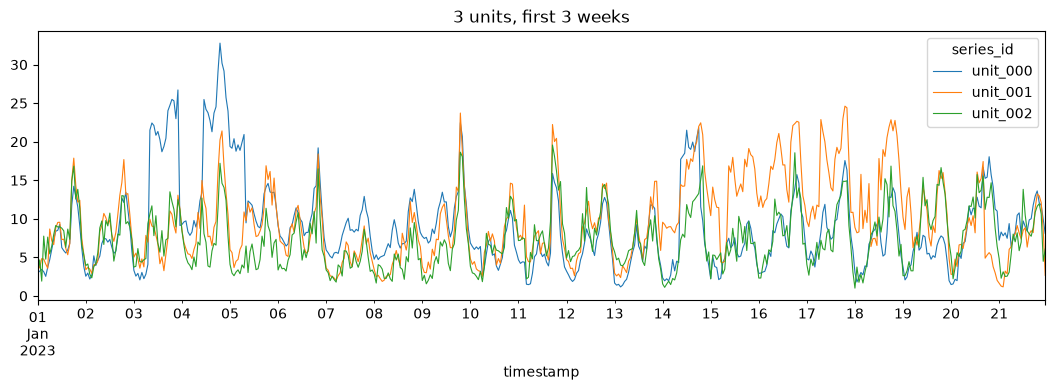

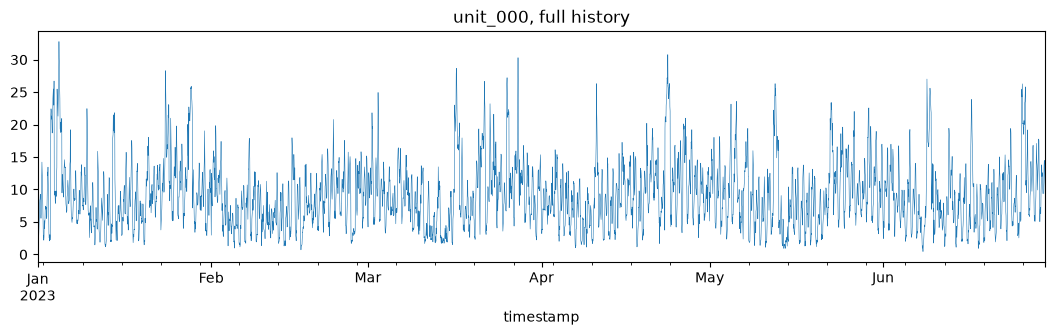

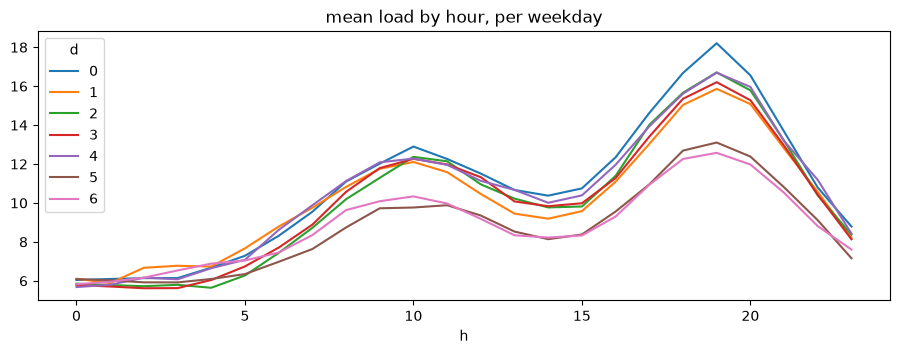

,mean,std,min,max
count,96.000000,96.000000,96.000000,96.000000
mean,9.912838,5.244396,0.597063,37.033670
std,1.658697,0.754265,0.271784,6.002615
min,6.451561,3.800635,0.164003,25.920340
25%,8.538404,4.574436,0.410199,32.485105
50%,10.059768,5.340088,0.526796,37.104069
75%,10.904685,5.722926,0.737483,40.892490
max,14.382911,7.123141,1.613256,53.000163


In [14]:
from pathlib import Path

piv = tr.pivot(index="timestamp", columns="series_id", values="target")

# A. three units, three weeks -> daily + weekly shape
piv.iloc[:504, :3].plot(figsize=(13,3.5), lw=.8)
plt.title("3 units, first 3 weeks")
plt.savefig("report/figures/first_3_weeks.png", dpi=300, bbox_inches="tight")
plt.show()

# B. one unit, full 180 days -> trend, level shifts, regime changes
piv["unit_000"].plot(figsize=(13,3), lw=.4)
plt.title("unit_000, full history")
plt.savefig("report/figures/full_history.png", dpi=300, bbox_inches="tight")
plt.show()

# C. average day-of-week x hour profile -> how strong is seasonality?
prof = tr.assign(h=tr.timestamp.dt.hour, d=tr.timestamp.dt.dayofweek) \
         .groupby(["d","h"]).target.mean().unstack(0)
prof.plot(figsize=(11,3.5)); plt.title("mean load by hour, per weekday")
plt.savefig("report/figures/mean_load_per_hr_per_weekday.png", dpi=300, bbox_inches="tight")
plt.show()

# D. how different are the units from each other?
tr.groupby("series_id").target.agg(["mean","std","min","max"]).describe()

### trend

In [15]:
print(tr.trend.min(), tr.trend.max())
print(tr.groupby("series_id").trend.mean().std())  # ~0 -> identical across units

-1.7317038770080473 1.2653824963831597
2.790127517638045e-17
